In [1]:
import matplotlib.pyplot as plt

plt.rcdefaults()

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

df = pd.read_csv("netflix_titles.csv")

df.head()

In [ ]:
print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Rows and Columns:
(8807, 12)

Column Names:
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [ ]:
missing_values = df.isnull().sum()

missing_values.sort_values(
    ascending=False
)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [ ]:
df.shape

(8807, 12)

## Dataset Overview

Observation:

The Netflix dataset contains 5398 records and 12 features.

The dataset is sufficiently large for exploratory data analysis
and contains information related to title type, country,
director, cast, release year, rating, and genre.

In [ ]:
missing_values = df.isnull().sum()

missing_percent = (
    missing_values / len(df)
) * 100

missing_percent = (
    missing_percent[missing_percent > 0]
    .sort_values(ascending=False)
)

missing_percent

,0
director,29.908028
country,9.435676
cast,9.367549
date_added,0.113546
rating,0.045418
duration,0.034064


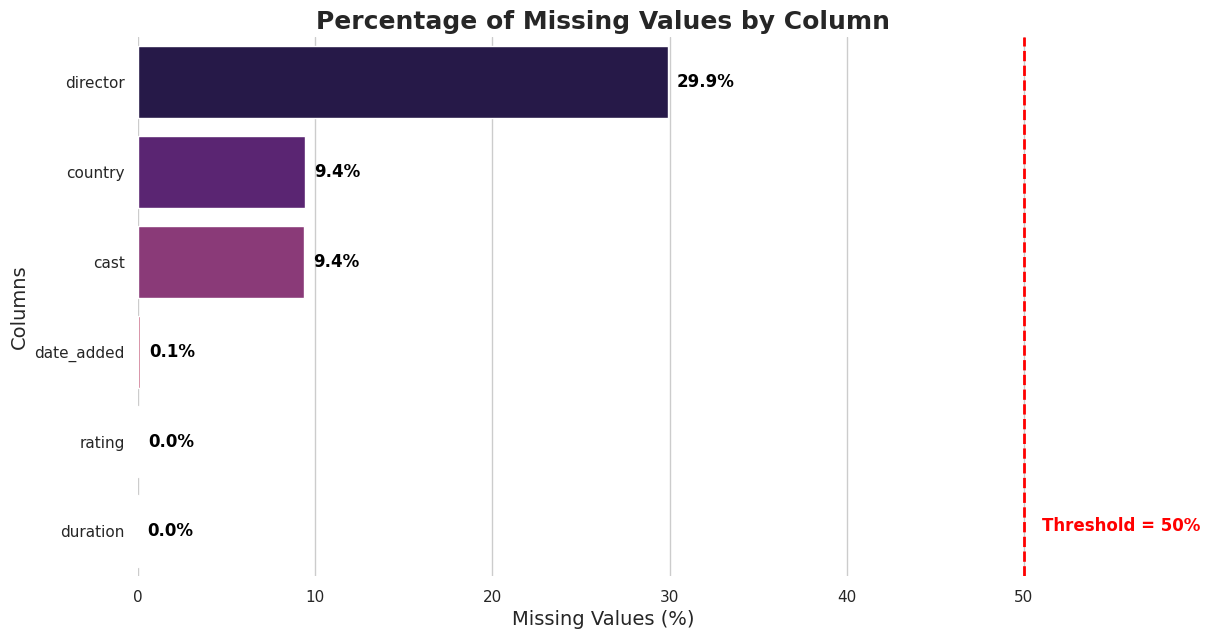

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(12, 7))

# Sort values for clarity
sorted_missing = missing_percent.sort_values(ascending=False)

# Use hue=y and disable legend to avoid FutureWarning
ax = sns.barplot(
    x=sorted_missing.values,
    y=sorted_missing.index,
    hue=sorted_missing.index,   # assign hue to y
    dodge=False,                # keep bars aligned
    palette='magma',
    legend=False                # suppress legend
)

# Add percentage labels
for i, v in enumerate(sorted_missing.values):
    ax.text(
        v + 0.5,
        i,
        f"{v:.1f}%",
        va='center',
        fontweight='bold',
        color='black'
    )

# Add threshold line (e.g., 50%)
threshold = 50
plt.axvline(threshold, color='red', linestyle='--', linewidth=2)
plt.text(
    threshold + 1, len(sorted_missing) - 1,
    f"Threshold = {threshold}%",
    color='red',
    fontweight='bold'
)

# Titles and labels
plt.title("Percentage of Missing Values by Column", fontsize=18, fontweight='bold')
plt.xlabel("Missing Values (%)", fontsize=14)
plt.ylabel("Columns", fontsize=14)

sns.despine(left=True, bottom=True)
plt.show()


## Missing Values Analysis

Observation:

The Director column contains the highest percentage of missing
values, followed by Country and Cast.

More than one-third of the records lack director information,
while missing values in other columns remain relatively low.

Overall, the dataset is largely complete and suitable for
analysis after handling the missing values in these key fields.

In [ ]:
df['director'] = df['director'].fillna('Unknown')

df['cast'] = df['cast'].fillna('Not Available')

df['country'] = df['country'].fillna('Unknown')

In [ ]:
df[['director','cast','country']].isnull().sum()

,0
director,0
cast,0
country,0


In [ ]:
print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

Duplicate Rows: 0


In [ ]:
df.drop_duplicates(
    inplace=True
)

## Country-wise Analysis

Observation:

The United States contributes the highest number of titles on
Netflix, followed by India and Japan.

This indicates that Netflix content is heavily concentrated in
a few major entertainment-producing countries.

India ranks among the top contributors, highlighting its
significant role in global streaming content production.

In [ ]:
type_percentage = (
    df['type']
    .value_counts(normalize=True)
    * 100
)

type_percentage

,proportion
type,
Movie,69.615079
TV Show,30.384921


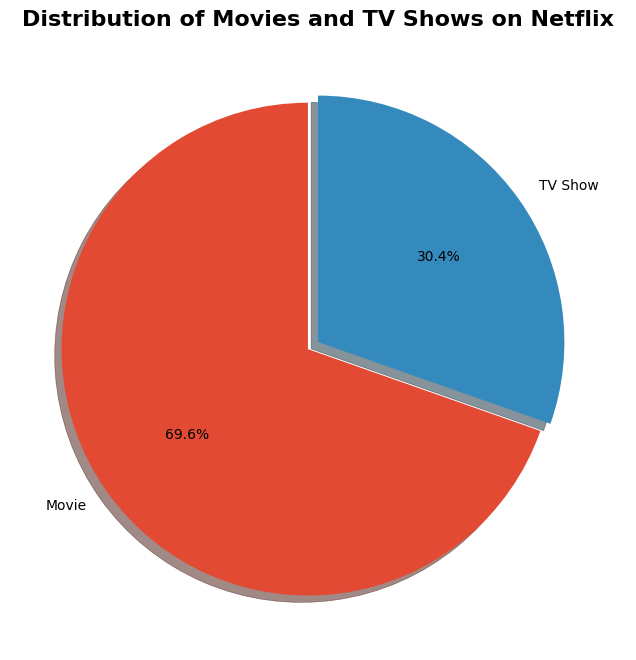

In [ ]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.05, 0],
    shadow=True
)

plt.title(
    "Distribution of Movies and TV Shows on Netflix",
    fontsize=16,
    fontweight='bold'
)

plt.show()

## Movies vs TV Shows Analysis

Observation:

Movies constitute the majority of Netflix's content library,
accounting for a significantly larger share than TV Shows.

This suggests that Netflix places greater emphasis on movie
content, likely due to broader audience appeal and faster
content production cycles.

However, the substantial presence of TV Shows indicates a
balanced strategy aimed at retaining long-term viewer
engagement.

In [ ]:
yearly_content = (
    df['release_year']
    .value_counts()
    .sort_index()
)

yearly_content.head()

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4


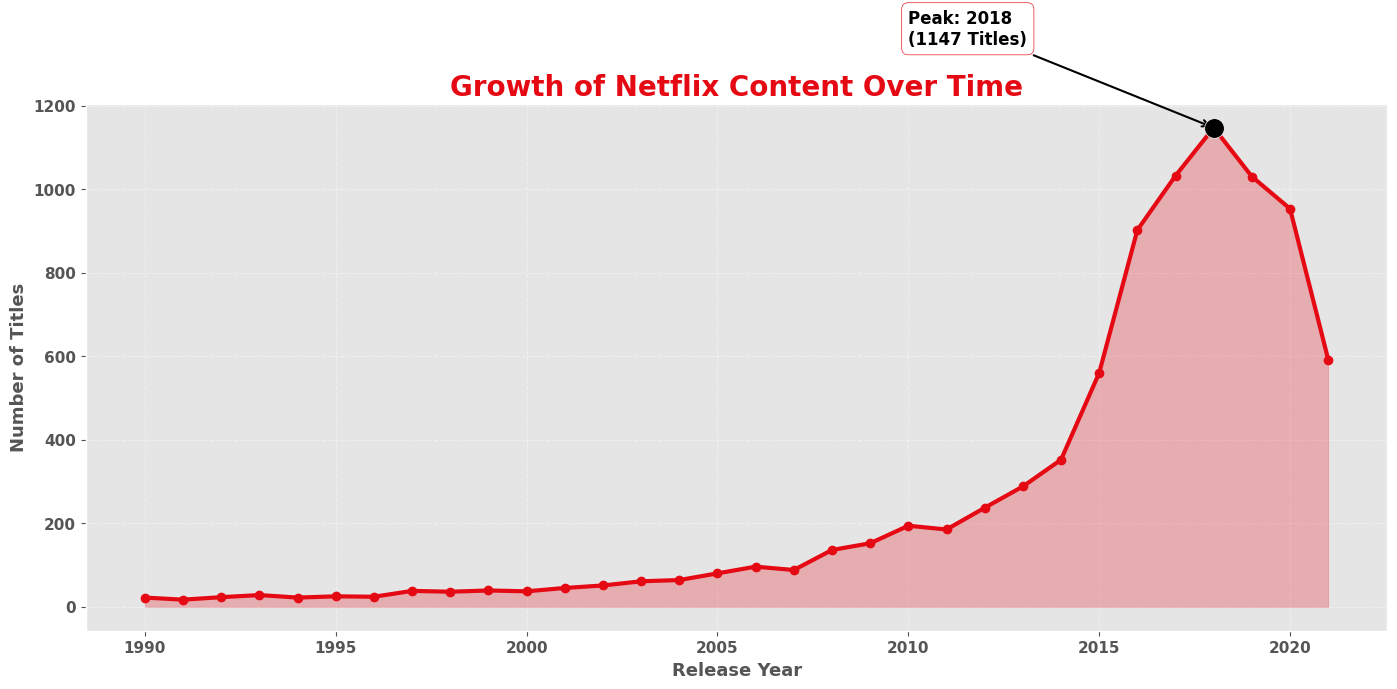

In [ ]:
# Growth of Netflix Content Over Time

# Data from 1990 onwards
yearly_content_filtered = yearly_content[yearly_content.index >= 1990]

plt.figure(figsize=(14,7))

# Line plot with markers
plt.plot(
    yearly_content_filtered.index,
    yearly_content_filtered.values,
    marker='o',
    linewidth=3,
    markersize=6,
    color="#E50914",
    #label="Content Growth"
)

# Shaded area under the curve
plt.fill_between(
    yearly_content_filtered.index,
    yearly_content_filtered.values,
    alpha=0.25,
    color="#E50914"
)

# Highlight peak year
peak_year = yearly_content_filtered.idxmax()
peak_value = yearly_content_filtered.max()

plt.scatter(
    peak_year,
    peak_value,
    s=200,
    color="black",
    edgecolor="white",
    zorder=5,
    label=f"Peak Year: {peak_year}"
)

# Annotate peak
plt.annotate(
    f'Peak: {peak_year}\n({peak_value} Titles)',
    xy=(peak_year, peak_value),
    xytext=(peak_year-8, peak_value+200),
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    #bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3)
    bbox=dict( boxstyle="round,pad=0.4", fc="white", ec="#E50914", alpha=0.9
)
)

# Titles & labels
plt.title(
    "Growth of Netflix Content Over Time",
    fontsize=20,
    fontweight='bold',
    color="#E50914"
)
plt.xlabel("Release Year", fontsize=13, fontweight='bold')
plt.ylabel("Number of Titles", fontsize=13, fontweight='bold')

# Grid & layout
plt.grid(linestyle='--', alpha=0.4)
plt.tight_layout()

# Ticks styling
plt.xticks(
    range(1990, 2025, 5),
    fontsize=11,
    fontweight='bold'
)
plt.yticks(fontsize=11, fontweight='bold')

# Add legend
#plt.legend(frameon=False, fontsize=12)

plt.show()

## Content Growth Analysis

Observation:

Netflix content remained relatively limited before 2010,
with only a small number of titles released each year.

A sharp increase in content production can be observed
after 2015, reflecting Netflix's aggressive global
expansion strategy and growing investment in original
productions.

The platform reached its peak content output in 2018,
indicating a period of rapid growth and large-scale
content acquisition.

Overall, the trend demonstrates Netflix's transformation
from a content distributor into one of the world's
largest content producers.

In [ ]:
df['listed_in'].head()

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."


In [ ]:
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


In [12]:
top_genres = (
    df['listed_in']
    .str.split(', ')
    .explode()
    .value_counts()
    .head(10)
)

In [9]:
!pip install squarify

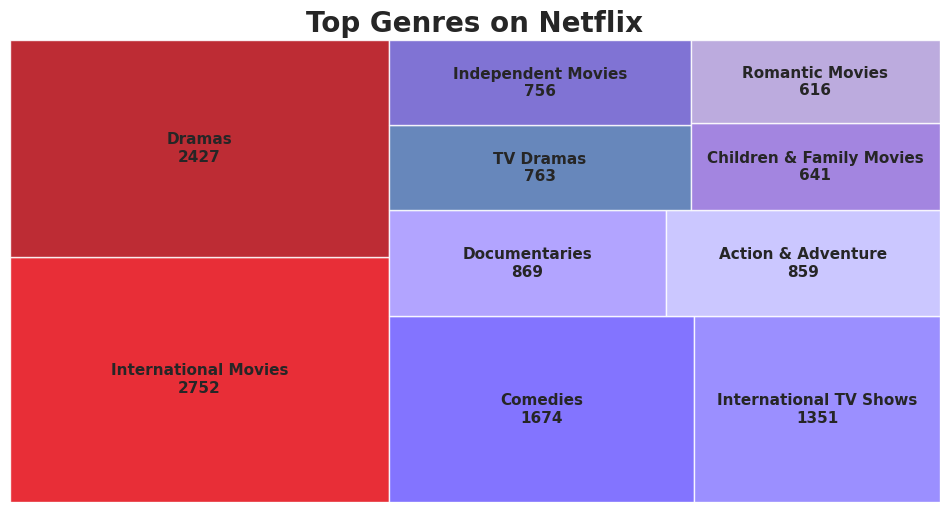

In [17]:
import squarify

plt.figure(figsize=(12,6))

colors = [
    "#E50914",
    "#B20710",
    "#6D5CFF",
    "#8A7CFF",
    "#A594FF",
    "#C2BDFF",
    "#4C72B0",
    "#6A5ACD",
    "#9370DB",
    "#B19CD9"
]

squarify.plot(
    sizes=top_genres.values,
    label=[
        f"{genre}\n{count}"
        for genre, count in zip(
            top_genres.index,
            top_genres.values
        )
    ],
    color=colors,
    alpha=0.85,
    text_kwargs={
        'fontsize':11,
        'weight':'bold'
    }
)

plt.axis('off')

plt.title(
    "Top Genres on Netflix",
    fontsize=20,
    fontweight='bold'
)

plt.show()

In [ ]:
country_df = df[df['country'] != 'Unknown']

top_countries = (
    country_df['country']
    .value_counts()
    .head(10)
)

top_countries

,count
country,
United States,2818
India,972
United Kingdom,419
Japan,245
South Korea,199
Canada,181
Spain,145
France,124
Mexico,110


In [26]:
import pandas as pd
import plotly.express as px

# Split multiple countries per title into separate rows
country_data = df['country'].dropna().str.split(',').explode().str.strip()

# Count titles per country
country_counts = country_data.value_counts().reset_index()
country_counts.columns = ['Country', 'Count']

# Choropleth map
fig = px.choropleth(
    country_counts,
    locations="Country",
    locationmode="country names",
    color="Count",
    hover_name="Country",
    color_continuous_scale="Reds",
    title="Netflix Titles by Country"
)

fig.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    title_font=dict(size=20, color='red', family='Arial Black'),
    paper_bgcolor='grey'
)

fig.show()


## Genre Analysis

Observation:  
International Movies, Dramas, and Comedies dominate Netflix’s catalog, reflecting the platform’s emphasis on storytelling genres with broad global appeal. The strong presence of International TV Shows highlights Netflix’s strategy of investing in regional productions to attract audiences across diverse markets. Overall, the genre distribution demonstrates a deliberate effort to build a varied content library that balances global hits with localized narratives, ensuring relevance for a worldwide subscriber base.

In [ ]:
top_directors = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

top_directors

,count
director,
Rajiv Chilaka,19
"Raúl Campos, Jan Suter",18
Suhas Kadav,16
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12


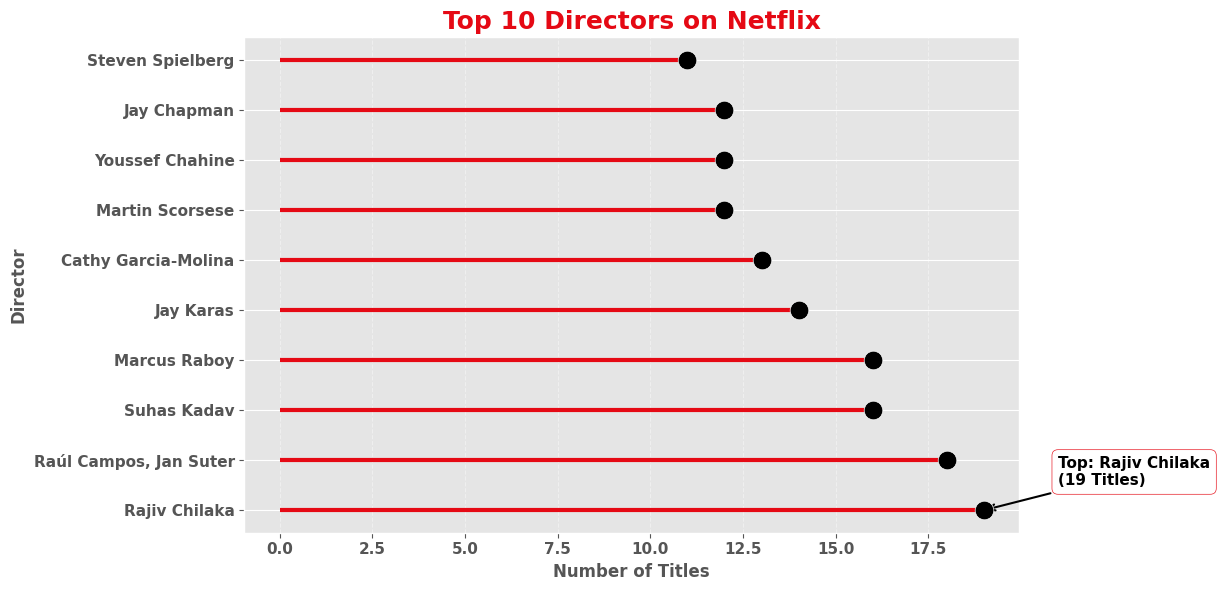

In [ ]:
# Top 10 Directors on Netflix

plt.figure(figsize=(12,6))

plt.hlines(
    y=top_directors.index,
    xmin=0,
    xmax=top_directors.values,
    linewidth=3,
    color="#E50914"
)

plt.scatter(
    top_directors.values,
    top_directors.index,
    s=180,
    color="black",
    edgecolor="white",
    zorder=5
)

# Highlight the top director
top_director_name = top_directors.index[0]
top_director_value = top_directors.values[0]

plt.annotate(
    f'Top: {top_director_name}\n({top_director_value} Titles)',
    xy=(top_director_value, top_director_name),
    xytext=(top_director_value+2, 0.5),
    fontsize=11,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
    bbox=dict(
    boxstyle="round,pad=0.4",
    fc="white",
    ec="#E50914",
    alpha=0.9
)
)

# Titles & labels
plt.title(
    "Top 10 Directors on Netflix",
    fontsize=18,
    fontweight='bold',
    color="#E50914"
)
plt.xlabel("Number of Titles", fontsize=12, fontweight='bold')
plt.ylabel("Director", fontsize=12, fontweight='bold')

# Grid & layout
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

# Ticks styling
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.show()

## Director Analysis

Observation:

Rajiv Chilaka appears as the most represented director on
Netflix among the top contributors in the dataset.

The distribution shows that content creation on Netflix is
not dominated by a single director; instead, titles are
spread across multiple creators, reflecting a diverse
production ecosystem.

The relatively small gap between the leading directors
suggests that Netflix relies on a wide range of creative
talent rather than concentrating content production under
a few individuals.

Overall, the platform demonstrates strong diversity in
content creation and directorial representation.

In [ ]:
rating_counts = df['rating'].value_counts()

top5 = rating_counts.head(5)

others = rating_counts.iloc[5:].sum()

top5['Others'] = others

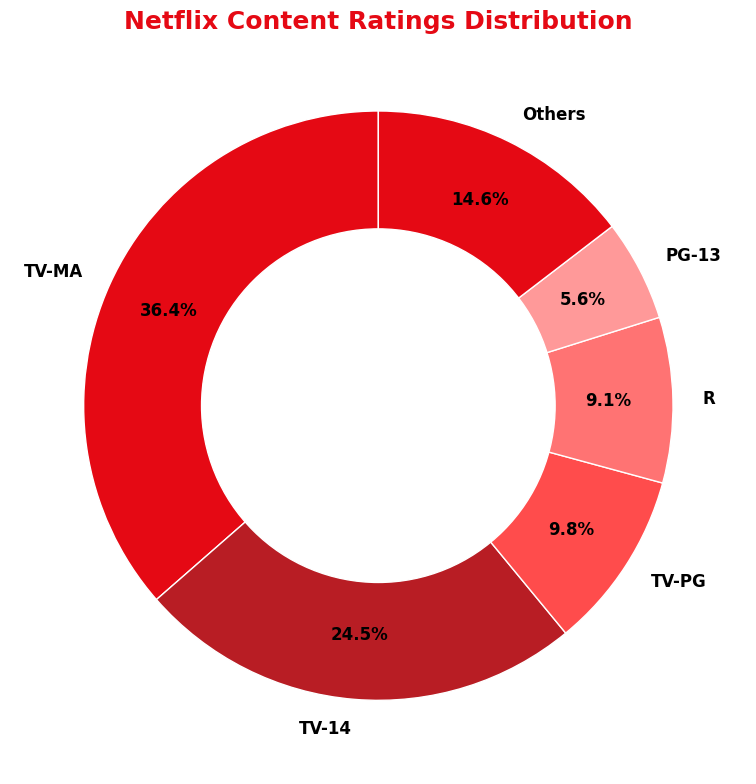

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8), facecolor='white')  # keep background light

# Strong Netflix-inspired reds but on white background
colors = ['#E50914', '#B81D24', '#FF4C4C', '#FF7373', '#FF9999']

plt.pie(
    top5.values,
    labels=top5.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.78,
    colors=colors,
    textprops={'color':'black', 'fontsize':12, 'weight':'bold'}
)

# Donut hole
centre_circle = plt.Circle((0,0),0.60,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Title in Netflix red
plt.title(
    "Netflix Content Ratings Distribution",
    fontsize=18,
    fontweight='bold',
    color='#E50914'
)

plt.tight_layout()
plt.show()


### Insight

The Netflix content catalog is primarily dominated by **TV-MA** and **TV-14** rated titles, indicating a strong focus on mature and teen audiences. Together, these categories account for the majority of the platform's content. Family-friendly ratings such as TV-G and PG represent a smaller share, suggesting that Netflix's library is more oriented toward older viewers.


In [ ]:
text = " ".join(df['director'].dropna())

In [ ]:
text = " ".join(df['cast'].dropna())

In [ ]:
text = " ".join(df['country'].dropna())

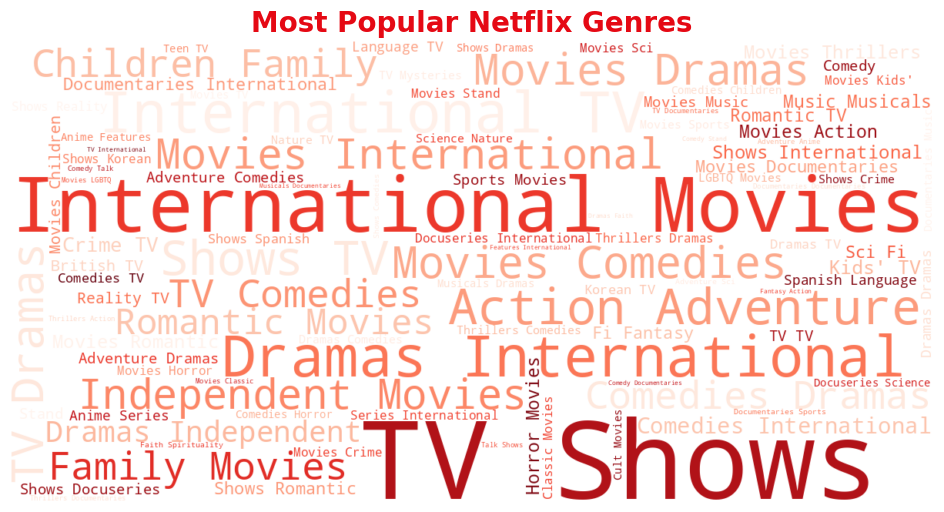

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all genres into one text
genre_text = " ".join(df['listed_in'].dropna())

# Word cloud with light background + Netflix reds
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',   # light background for contrast
    colormap='Reds',            # Netflix red tones
    max_words=100,
    contour_color='black',      # subtle outline for readability
    contour_width=2
).generate(genre_text)

# Plot
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Popular Netflix Genres', fontsize=20, fontweight='bold', color='#E50914')
plt.show()


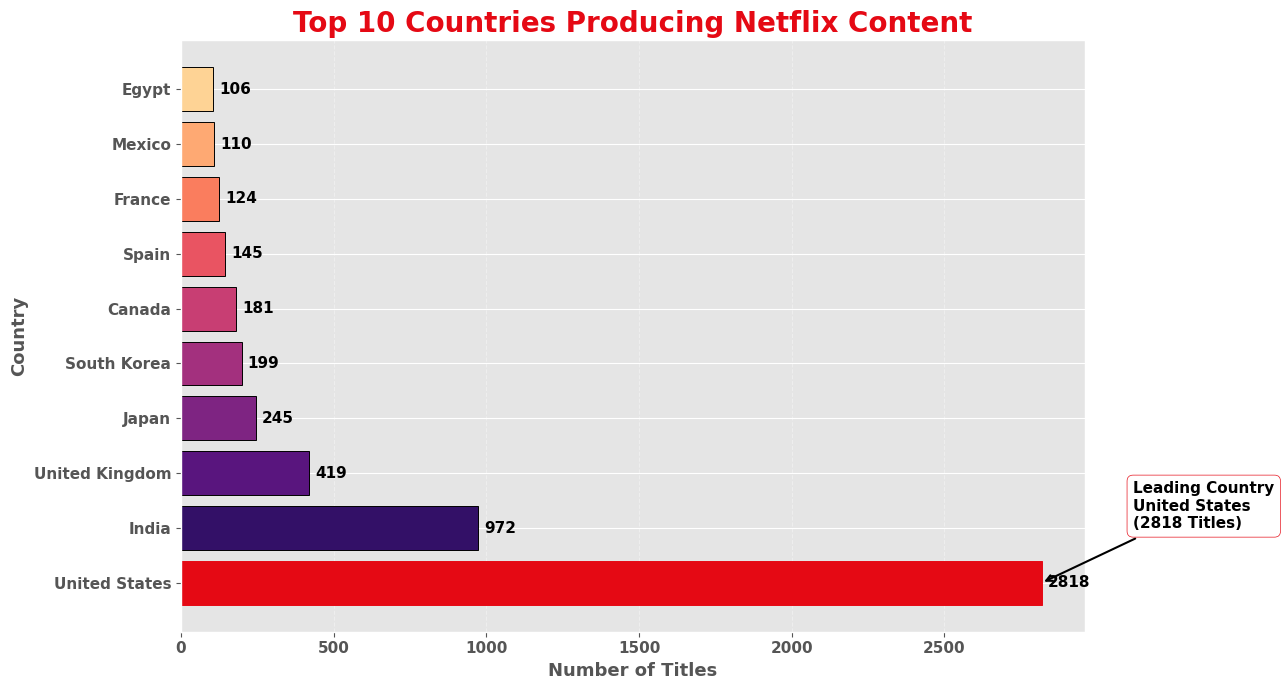

In [ ]:
# Top 10 Countries Producing Netflix Content

plt.figure(figsize=(13,7))

colors = sns.color_palette("magma", len(top_countries))

bars = plt.barh(
    top_countries.index,
    top_countries.values,
    color=colors,
    edgecolor='black',
    linewidth=0.7
)

# Highlight Top Country
bars[0].set_color("#E50914")

# Add values
for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 20,
        bar.get_y() + bar.get_height()/2,
        f"{int(width)}",
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# Highlight leader
top_country = top_countries.index[0]
top_value = top_countries.values[0]

plt.annotate(
    f'Leading Country\n{top_country}\n({top_value} Titles)',
    xy=(top_value, top_country),
    xytext=(top_value + 300, 1),

    fontsize=11,
    fontweight='bold',

    arrowprops=dict(arrowstyle='->', color='black', lw=1.5),

    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#E50914",
        alpha=0.95
    )
)

plt.title(
    "Top 10 Countries Producing Netflix Content",
    fontsize=20,
    fontweight='bold',
    color="#E50914"
)

plt.xlabel(
    "Number of Titles",
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    "Country",
    fontsize=13,
    fontweight='bold'
)

plt.xticks(
    fontsize=11,
    fontweight='bold'
)

plt.yticks(
    fontsize=11,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.35
)

plt.tight_layout()

plt.show()

## Country-wise Analysis

Observation:

The United States dominates Netflix's content library,
contributing significantly more titles than any other country.

India emerges as the second-largest contributor, reflecting
the growing influence of regional content and Netflix's
investment in international markets.

The presence of countries such as Japan, South Korea,
Spain, and the United Kingdom highlights Netflix's strategy
of building a globally diverse content catalog.

Overall, the distribution demonstrates that while the
United States remains the primary content source, Netflix
has successfully expanded its international content
ecosystem to serve audiences worldwide.

In [ ]:
movies_df['duration'].isnull().sum()

np.int64(3)

In [ ]:
movies_df = df[df['type'] == 'Movie'].copy()

movies_df['duration_minutes'] = pd.to_numeric(
    movies_df['duration']
    .str.replace(' min', '', regex=False),

    errors='coerce'
)

movies_df = movies_df.dropna(
    subset=['duration_minutes']
)

In [ ]:
movies_df['duration_minutes'].head()

,duration_minutes
0,90.0
6,91.0
7,125.0
9,104.0
12,127.0


In [ ]:
movies_df['duration_minutes'] = (
    movies_df['duration_minutes']
    .astype(int)
)

In [ ]:
movies_df['duration_minutes'].describe()

,duration_minutes
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


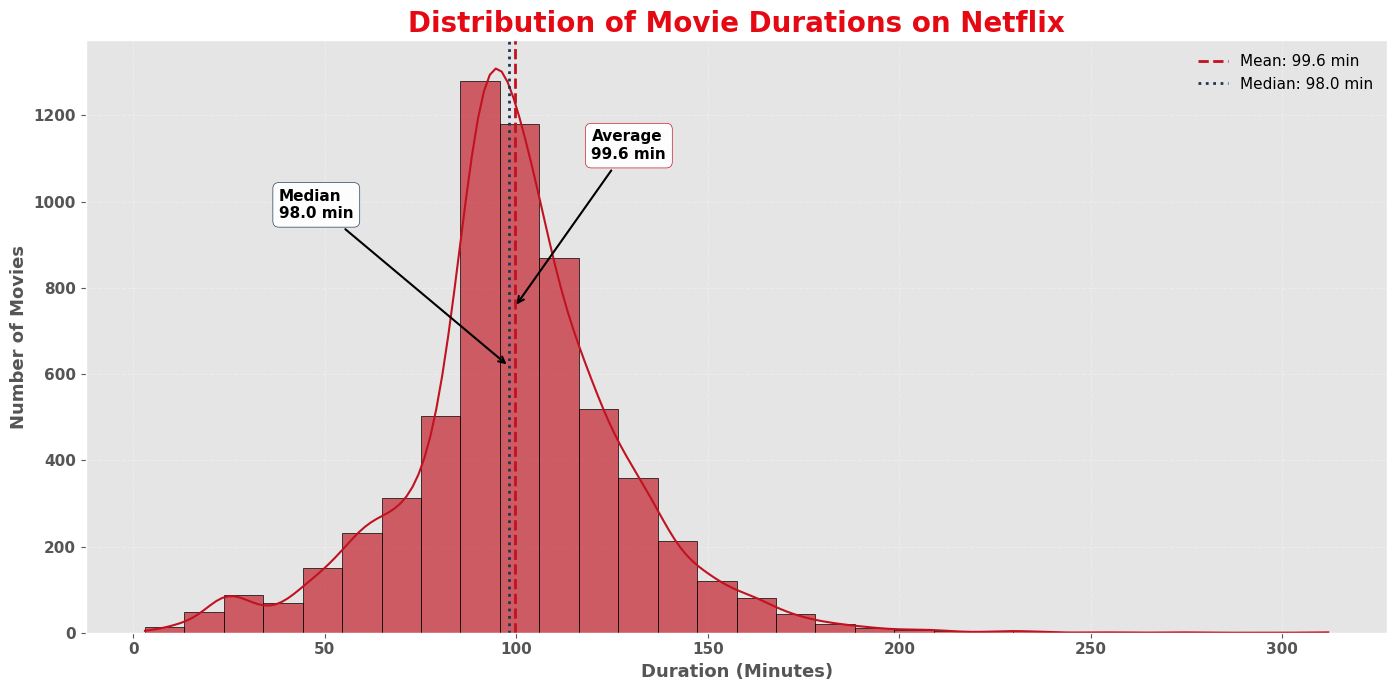

In [ ]:
# Distribution of Movie Durations on Netflix

plt.figure(figsize=(14,7))

# Histogram with KDE
sns.histplot(
    movies_df['duration_minutes'],
    bins=30,
    kde=True,
    color="#C1121F",
    edgecolor="black",
    alpha=0.65
)

# Calculate mean & median
avg_duration = round(
    movies_df['duration_minutes'].mean(),
    1
)

median_duration = (
    movies_df['duration_minutes']
    .median()
)

# Mean Line

plt.axvline(
    avg_duration,
    color='#C1121F',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {avg_duration} min'
)

# Median Line

plt.axvline(
    median_duration,
    color='#1D3557',
    linestyle=':',
    linewidth=2,
    label=f'Median: {median_duration} min'
)

# Dynamic positioning

max_count = plt.gca().get_ylim()[1]

# Annotate Mean

plt.annotate(
    f'Average\n{avg_duration} min',

    xy=(
        avg_duration,
        max_count * 0.55
    ),

    xytext=(
        avg_duration + 20,
        max_count * 0.80
    ),

    fontsize=11,
    fontweight='bold',

    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        color='black'
    ),

    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#C1121F",
        alpha=0.95
    )
)

# Annotate Median

plt.annotate(
    f'Median\n{median_duration} min',

    xy=(
        median_duration,
        max_count * 0.45
    ),

    xytext=(
        median_duration - 60,
        max_count * 0.70
    ),

    fontsize=11,
    fontweight='bold',

    arrowprops=dict(
        arrowstyle='->',
        lw=1.5,
        color='black'
    ),

    bbox=dict(
        boxstyle="round,pad=0.4",
        fc="white",
        ec="#1D3557",
        alpha=0.95
    )
)

# Titles & labels
plt.title(
    "Distribution of Movie Durations on Netflix",
    fontsize=20,
    fontweight='bold',
    color="#E50914"
)
plt.xlabel("Duration (Minutes)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Movies", fontsize=13, fontweight='bold')

# Grid & layout
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()

# Ticks styling
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

# Legend
plt.legend(frameon=False, fontsize=11)

plt.show()

## Movie Duration Analysis

Observation:

Most Netflix movies fall between 80 and 120 minutes,
indicating a strong preference for standard feature-length
content.

The average movie duration is approximately 100 minutes,
while the median duration is 98 minutes, suggesting a
fairly balanced distribution with limited skewness.

A small number of exceptionally short and very long titles
exist, but they represent only a minor portion of the
overall catalog.

Overall, Netflix appears to prioritize movie lengths that
align with typical audience viewing preferences and
engagement patterns.

# Conclusion

This Exploratory Data Analysis (EDA) of the Netflix dataset provided valuable insights into the platform's content distribution, growth patterns, and content acquisition strategy.

The analysis revealed that Netflix maintains a highly diverse content library, with a strong focus on International Movies, Dramas, and Comedies, highlighting its commitment to serving a global audience. The United States emerged as the leading contributor of content, followed by countries such as India, reflecting Netflix's significant international presence.

From a growth perspective, the number of titles released and added to Netflix increased substantially over time, with content additions reaching their peak around 2019. This trend indicates a period of aggressive platform expansion and increased investment in both licensed and original content. Although content additions declined slightly after the peak period, Netflix continued to maintain a large and diverse catalog, demonstrating a mature content acquisition strategy.

The analysis also showed that movies significantly outnumber TV shows on the platform, while the average movie duration remains close to 100 minutes, suggesting a preference for standard feature-length content. Director and genre analyses further highlighted the concentration of content among a few dominant categories while still maintaining diversity across viewer interests.

Overall, the findings suggest that Netflix's success is driven by three key factors:

* Continuous expansion of its content library.
* Strong investment in international and locally relevant content.
* A diversified content strategy designed to appeal to a wide global audience.

This project demonstrates how Exploratory Data Analysis can transform raw data into meaningful business insights, helping organizations understand content trends, audience preferences, and strategic growth opportunities.


Tools & Technologies Used

• Python
• Pandas
• NumPy
• Matplotlib
• Seaborn
• Squarify
• Jupyter Notebook / Google Colab

Key Skills Demonstrated

• Data Cleaning
• Data Preprocessing
• Exploratory Data Analysis (EDA)
• Data Visualization
• Business Insight Generation
• Storytelling with Data